# Лекция 4. Разбор упражнений

Упражнения из раздела 12 конспекта [`lecture04.md`](lecture04.md). Формат одинаковый: условие и его суть → разбор по пунктам → проверка кодом, по одной идее на ячейку.

На семинаре: 12.9 (цепь аналитически, у доски) и 12.10 (CasADi, за ноутбуком). Всё остальное — 12.0–12.8 и 12.11 — дома. Сначала попробуйте решить сами; краткие ответы без кода — [`exercises04.md`](exercises04.md).

В проверках используются две функции из демо: `gd` — градиентный спуск (постоянный шаг или backtracking) и `newton` — чистый метод Ньютона. Их код — в файле [`l4helpers.py`](l4helpers.py), который подключает первая ячейка.

In [1]:
%matplotlib inline

from l4helpers import *  # палитра, настройки matplotlib, функции gd и newton (см. файл рядом)

## 12.0. Разминка — счёт руками

> Шесть пунктов на повторение, каждый решается на бумаге за минуту. (а) $\nabla f$ и $\nabla^2f$ для $3x_1^2-2x_1x_2+x_2^2+5x_1$. (б) Два шага спуска на $\tfrac12(x_1^2+9x_2^2)$ из $(2,1)$, $\alpha=0.1$. (в) Собственные числа $\begin{pmatrix}6&-2\\-2&2\end{pmatrix}$ и $\kappa$. (г) Безопасные шаги и $1/L$ для неё. (д) Выпуклы ли $e^{x_1}+x_2^2$ и $x_1x_2$? (е) Стационарные точки $x^3-3x$.
>
> *Суть: держать руки тёплыми — градиенты, гессианы и шаги без компьютера.*

**(а)** По координатам: $\nabla f=(6x_1-2x_2+5,\ -2x_1+2x_2)$, гессиан постоянный: $\nabla^2f=\begin{pmatrix}6&-2\\-2&2\end{pmatrix}$.

**(б)** $\nabla f=(x_1,\ 9x_2)$, шаг даёт $\big(0.9\,x_1,\ 0.1\,x_2\big)$: из $(2,\,1)$ в $(1.8,\ 0.1)$, затем в $(1.62,\ 0.01)$. Координаты сжимаются в $1-\alpha=0.9$ и $1-9\alpha=0.1$ раза за шаг — те самые множители $|1-\alpha\lambda_i|$ из 12.3.

**(в)** След $8$, определитель $6\cdot2-(-2)^2=8$: $\lambda^2-8\lambda+8=0$, $\lambda=4\pm2\sqrt2\approx6.83$ и $1.17$. Число обусловленности $\kappa=\dfrac{4+2\sqrt2}{4-2\sqrt2}=3+2\sqrt2\approx5.8$.

**(г)** $L=\lambda_{\max}=4+2\sqrt2\approx6.83$: безопасны шаги $0<\alpha<2/L\approx0.29$, а лучший гарантированный — $1/L\approx0.15$.

**(д)** $\nabla^2(e^{x_1}+x_2^2)=\operatorname{diag}(e^{x_1},\,2)\succ0$ — выпукла. У $x_1x_2$ гессиан $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ с собственными числами $\pm1$ — индефинитен, не выпукла (седло в нуле).

**(е)** $g'=3x^2-3=0$ даёт $x=\pm1$; $g''=6x$: в $x=1$ положительна — локальный минимум, в $x=-1$ отрицательна — локальный максимум. Глобальных экстремумов нет: $x^3$ уходит в $\pm\infty$.

In [2]:
# (б)-(в): проверяем арифметику разминки
A = np.array([[6.0, -2.0], [-2.0, 2.0]])
lam = np.linalg.eigvalsh(A)
print(f"(в) собственные числа {lam.round(3)}; 4 -/+ 2 sqrt(2) = {4 - 2 * np.sqrt(2):.3f}, {4 + 2 * np.sqrt(2):.3f};  kappa = {lam[1] / lam[0]:.3f} = 3 + 2 sqrt(2) = {3 + 2 * np.sqrt(2):.3f}")

x = np.array([2.0, 1.0])
for _ in range(2):
    x = x - 0.1 * np.array([x[0], 9 * x[1]])
    print(f"(б) шаг: x = {x.round(4)}")
assert np.allclose(x, [1.62, 0.01])

(в) собственные числа [1.172 6.828]; 4 -/+ 2 sqrt(2) = 1.172, 6.828;  kappa = 5.828 = 3 + 2 sqrt(2) = 5.828
(б) шаг: x = [1.8 0.1]
(б) шаг: x = [1.62 0.01]


## 12.1. Стационарные точки и седло

> $f(x)=(x_1^2-1)^2+x_2^2$. (а) Найдите все точки с $\nabla f=0$. (б) Классифицируйте по гессиану. (в) Куда придёт спуск из $(0,\,0.5)$? Из $(0.01,\,0.5)$?
>
> *Суть: спуск гарантирует только $\nabla f=0$, и седло его ловит.*

**(а)** $\nabla f=\big(4x_1(x_1^2-1),\ 2x_2\big)$. Вторая компонента — нуль только при $x_2=0$; первая — при $x_1\in\{0,\,1,\,-1\}$. Три точки: $(0,0)$, $(1,0)$, $(-1,0)$.

**(б)** Смешанных производных нет: $\nabla^2f=\operatorname{diag}(12x_1^2-4,\ 2)$.

- $(0,0)$: $\operatorname{diag}(-4,\,2)$, знаки разные — **седло**.
- $(\pm1,0)$: $\operatorname{diag}(8,\,2)\succ0$ — **строгие минимумы**; там $f=0$, а $f\ge0$ всюду, так что оба глобальные.
- Максимумов нет: $f$ не ограничена сверху.

**(в) Старт $(0,\,0.5)$.** При $x_1=0$ первая компонента градиента — нуль, и шаг её не меняет: вся траектория живёт на прямой $x_1=0$. На этой прямой $f=1+x_2^2$ — парабола с минимумом в $x_2=0$, и метод сходится к **седлу** $(0,0)$. Критерий $\|\nabla f\|\le\varepsilon$ подвоха не заметит: в седле градиент тоже нулевой.

**Старт $(0.01,\,0.5)$.** Теперь покоординатно $x_1\leftarrow x_1\big(1+4\alpha(1-x_1^2)\big)$: при $|x_1|<1$ скобка больше единицы, и модуль $x_1$ **растёт**. А $x_2\leftarrow(1-2\alpha)x_2$ затухает. Точка уходит от седла и приходит в минимум $(1,0)$.

**Мораль.** Спуск сходится к стационарной точке, не обязательно к минимуму, — но к седлу лишь со множества стартов меры нуль (здесь — прямая $x_1=0$): вдоль направления с $\lambda<0$ ошибка растёт, и любое возмущение уводит. «Мера нуль» держится и в float: $4\cdot0\cdot(0-1)$ — нуль точно, без ошибок округления.

In [3]:
f1 = lambda x: (x[0] ** 2 - 1) ** 2 + x[1] ** 2
g1 = lambda x: np.array([4 * x[0] * (x[0] ** 2 - 1), 2 * x[1]])
h1 = lambda x: np.diag([12 * x[0] ** 2 - 4, 2.0])

# (а)-(б): три стационарные точки и их классификация по собственным числам
for p in ([0.0, 0.0], [1.0, 0.0], [-1.0, 0.0]):
    lam = np.linalg.eigvalsh(h1(p))
    kind = "минимум" if lam.min() > 0 else ("максимум" if lam.max() < 0 else "седло")
    print(f"x = {p}: grad = {g1(p)}, lambda = {lam} -> {kind}")

x = [0.0, 0.0]: grad = [-0.  0.], lambda = [-4.  2.] -> седло
x = [1.0, 0.0]: grad = [0. 0.], lambda = [2. 8.] -> минимум
x = [-1.0, 0.0]: grad = [-0.  0.], lambda = [2. 8.] -> минимум


In [4]:
# (в): два старта на расстоянии 0.01 — два разных исхода
xa, ka, pa = gd(f1, g1, [0.0, 0.5])
xb, kb, pb = gd(f1, g1, [0.01, 0.5])
print(f"из (0, 0.5):    пришли в {xa.round(6)} за {ka} итераций — седло")
print(f"из (0.01, 0.5): пришли в {xb.round(6)} за {kb} итераций — минимум")
assert np.allclose(xa, [0, 0], atol=1e-6) and np.allclose(xb, [1, 0], atol=1e-5)

из (0, 0.5):    пришли в [0. 0.] за 1 итераций — седло
из (0.01, 0.5): пришли в [1. 0.] за 16 итераций — минимум


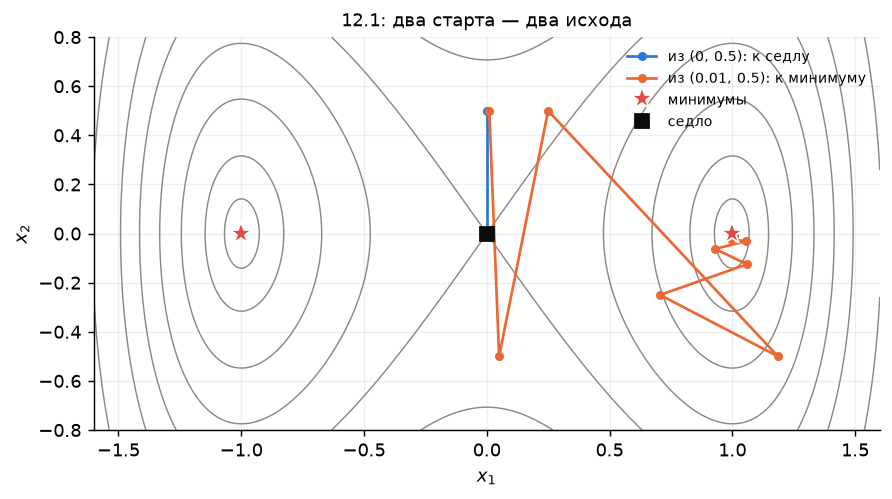

In [5]:
xx, yy = np.meshgrid(np.linspace(-1.6, 1.6, 300), np.linspace(-0.8, 0.8, 200))
zz = (xx ** 2 - 1) ** 2 + yy ** 2
fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.contour(xx, yy, zz, levels=np.r_[0.02, 0.1, 0.3, 0.6, 1.0, 1.5, 2.5], colors=GRAY, linewidths=0.8)
ax.plot(pa[:, 0], pa[:, 1], "-o", ms=4, color=BLUE, label="из $(0,\,0.5)$: к седлу")
ax.plot(pb[:, 0], pb[:, 1], "-o", ms=4, color=ORANGE, label="из $(0.01,\,0.5)$: к минимуму")
ax.plot([1, -1], [0, 0], "*", ms=13, color=RED, mec="white", ls="none", label="минимумы")
ax.plot([0], [0], "s", ms=8, color=INK, ls="none", label="седло")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=8); ax.set_title("12.1: два старта — два исхода", fontsize=10)
plt.show()

## 12.2. Зазор между необходимым и достаточным

> (а) $x^4$, $x^3$, $-x^4$ в нуле: что говорят условия и что на самом деле? (б) $f=x_1^2+x_2^4$ и $g=x_1^2-x_2^4$: гессианы в нуле одинаковы, а поведение разное. Почему? (в) Пеано, $f=(x_2-x_1^2)(x_2-2x_1^2)$: проверьте $\nabla f(0)=0$, $\nabla^2f(0)=\operatorname{diag}(0,2)$. (г) Покажите: на каждой прямой через нуль — строгий минимум. (д) Найдите $f<0$ сколь угодно близко к нулю.
>
> *Суть: при нулевом собственном числе гессиана условия второго порядка молчат — решают старшие члены.*

**(а)** У всех трёх $f'(0)=f''(0)=0$: необходимые условия выполнены, достаточное ($f''>0$) — нет. На деле $x^4$ — минимум, $x^3$ — перегиб (не экстремум), $-x^4$ — максимум: решают члены выше второго порядка, которых условия не видят.

**(б)** Оба гессиана в нуле равны $\operatorname{diag}(2,\,0)\succeq0$. Но $f=x_1^2+x_2^4\ge0$ — минимум, а $g(0,x_2)=-x_2^4<0$ — **седло**: вдоль вырожденного направления ($\lambda=0$) всё решает четвёртая степень, и она у них разная.

**(в)** Раскроем скобки: $f=x_2^2-3x_1^2x_2+2x_1^4$. Тогда $\nabla f=\big(-6x_1x_2+8x_1^3,\ 2x_2-3x_1^2\big)$ — в нуле нуль. Вторые производные в нуле дают $\nabla^2f(0)=\operatorname{diag}(0,\,2)\succeq0$: необходимые условия выполнены, достаточное — нет, направление $e_1$ вырождено.

**(г)** Прямая $x_2=mx_1$: $f=x_1^2(m-x_1)(m-2x_1)$. При $m\ne0$ и малых $x_1$ обе скобки близки к $m$, так что $f\approx m^2x_1^2>0$. На оси $x_1$ ($m=0$): $f=2x_1^4>0$; на оси $x_2$: $f=x_2^2>0$. На **каждой** прямой в нуле строгий локальный минимум.

**(д)** $f<0$ ровно там, где скобки разных знаков: между параболами $x_1^2<x_2<2x_1^2$. На средней параболе $x_2=\tfrac32x_1^2$ выходит $f=-\tfrac14x_1^4<0$ при любом $x_1\ne0$ — сколь угодно близко к нулю. Значит, нуль — **не минимум**, хотя на каждой прямой выглядел минимумом: к точке можно подходить и по кривым. Гарантию даёт только $\nabla^2f(0)\succ0$ — равномерная по направлениям оценка $\tfrac{\lambda_{\min}}2\|d\|^2$, которой здесь нет.

In [6]:
fp = lambda x1, x2: (x2 - x1 ** 2) * (x2 - 2 * x1 ** 2)

# (г): вдоль прямых через нуль f > 0 при малых t
t = np.r_[-np.logspace(-3, -1, 7), np.logspace(-3, -1, 7)]
worst = min(fp(t * np.cos(th), t * np.sin(th)).min() for th in np.linspace(0, np.pi, 12)[:-1])
print(f"(г) минимум f вдоль 11 прямых через нуль при 0 < |t| <= 0.1: {worst:.2e} > 0")
assert worst > 0

# (д): на параболе x2 = 1.5 x1^2 функция отрицательна сколь угодно близко к нулю
for x1 in (0.1, 0.01, 0.001):
    print(f"(д) f({x1}, 1.5*{x1}^2) = {fp(x1, 1.5 * x1 ** 2):.3e}  (= -x1^4/4 = {-x1 ** 4 / 4:.3e})")
assert all(fp(x1, 1.5 * x1 ** 2) < 0 for x1 in (0.1, 0.01, 0.001))

(г) минимум f вдоль 11 прямых через нуль при 0 < |t| <= 0.1: 2.00e-12 > 0
(д) f(0.1, 1.5*0.1^2) = -2.500e-05  (= -x1^4/4 = -2.500e-05)
(д) f(0.01, 1.5*0.01^2) = -2.500e-09  (= -x1^4/4 = -2.500e-09)
(д) f(0.001, 1.5*0.001^2) = -2.500e-13  (= -x1^4/4 = -2.500e-13)


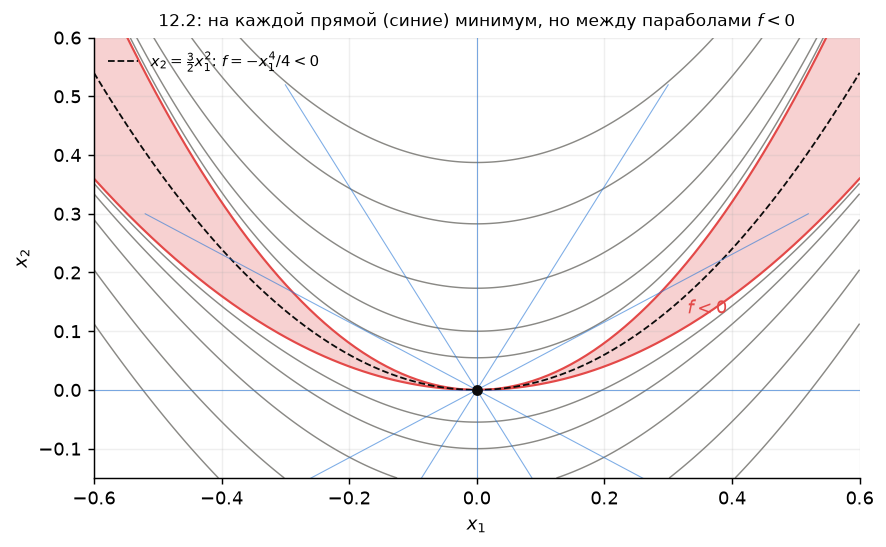

In [7]:
xx, yy = np.meshgrid(np.linspace(-0.6, 0.6, 400), np.linspace(-0.15, 0.6, 400))
zz = (yy - xx ** 2) * (yy - 2 * xx ** 2)
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.contourf(xx, yy, zz, levels=[zz.min(), 0], colors=[RED], alpha=0.25)
ax.contour(xx, yy, zz, levels=np.r_[0.003, 0.01, 0.03, 0.08, 0.15], colors=GRAY, linewidths=0.8)
xs = np.linspace(-0.6, 0.6, 200)
ax.plot(xs, xs ** 2, color=RED, lw=1.2); ax.plot(xs, 2 * xs ** 2, color=RED, lw=1.2)
ax.plot(xs, 1.5 * xs ** 2, "--", color=INK, lw=1, label="$x_2=\\frac{3}{2}x_1^2$: $f=-x_1^4/4<0$")
for th in np.linspace(0, np.pi, 7)[:-1]:
    ax.plot([-0.6 * np.cos(th), 0.6 * np.cos(th)], [-0.6 * np.sin(th), 0.6 * np.sin(th)], color=BLUE, lw=0.6, alpha=0.6)
ax.plot(0, 0, "o", color=INK, ms=5)
ax.text(0.33, 0.13, "$f<0$", color=RED, fontsize=10)
ax.set_xlim(-0.6, 0.6); ax.set_ylim(-0.15, 0.6)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.legend(fontsize=8.5, loc="upper left")
ax.set_title("12.2: на каждой прямой (синие) минимум, но между параболами $f<0$", fontsize=9.5)
plt.show()

## 12.3. Спуск на вытянутой квадратичной

> $f(x)=\tfrac12(x_1^2+\kappa x_2^2)$, $\kappa\ge1$, постоянный шаг $\alpha$. (а) Итерация покоординатно. (б) При каких $\alpha$ сходимость из любой точки? (в) Нарисуйте $|1-\alpha|$ и $|1-\alpha\kappa|$; какой шаг лучший? (г) $\kappa=50$: итераций на цифру при $\alpha=1/\kappa$ и при лучшем шаге; во сколько сжимается $f$? (д) Метры → километры: гессиан и $\kappa$? (е) Шаг с $D^{-1}$ — это спуск в метрах; $D=\nabla^2f$, $\alpha=1$ — Ньютон.
>
> *Суть: вся скорость спуска видна в двух числах $|1-\alpha|$ и $|1-\alpha\kappa|$.*

**(а)** $\nabla f=(x_1,\ \kappa x_2)$, и шаг расщепляется по координатам:
$$x_1\leftarrow(1-\alpha)\,x_1,\qquad x_2\leftarrow(1-\alpha\kappa)\,x_2.$$
Две независимые геометрические прогрессии. Минимум в нуле, так что $x$ — это и есть ошибка.

**(б)** Обе прогрессии затухают $\iff$ $|1-\alpha|<1$ и $|1-\alpha\kappa|<1$. Второе условие строже: $0<\alpha<2/\kappa$. При $\alpha>2/\kappa$ координата $x_2$ раскачивается с растущей амплитудой — расходимость из любого старта.

**(в)** Ошибка сжимается за шаг не хуже, чем в $\rho(\alpha)=\max\big(|1-\alpha|,\ |1-\alpha\kappa|\big)$ раз. На картинке ниже это две ломаные: пологая с нулём в $\alpha=1$ и крутая с нулём в $\alpha=1/\kappa$. Максимум двух минимален там, где они пересекаются: $1-\alpha=\alpha\kappa-1$, откуда
$$\alpha^\ast=\frac2{\kappa+1},\qquad \rho(\alpha^\ast)=\frac{\kappa-1}{\kappa+1}.$$

**(г)** Итераций на одну верную цифру — $n$ из $\rho^n=0.1$, то есть $n=\ln10/(-\ln\rho)$. При $\kappa=50$:

| шаг | множитель $\rho$ | итераций на цифру |
|---|---|---|
| $1/\kappa=0.02$ | $0.98$ | $\approx114$ |
| $\alpha^\ast=2/51\approx0.039$ | $49/51\approx0.961$ | $\approx58$ |

Лучший шаг вдвое быстрее, но оба $\sim\kappa$. Функция $f=\tfrac12x^\top Qx$ **квадратична** по ошибке, поэтому сама она сжимается в $\rho^2$ раз за шаг: $0.98^2=0.9604$ и $(49/51)^2\approx0.923$. Проверка ниже: из $(50,\,1)$ до $\|\nabla f\|\le10^{-8}$ — $1106$ итераций при $\alpha=1/\kappa$ и $567$ при $\alpha^\ast$; точный линейный поиск даёт те же $567$: знать $\kappa$ ему не нужно, но и быстрее лучшего постоянного шага он не бывает.

**(д)** Замена $x_1=1000\,u_1$: $\tilde f(u)=\tfrac12\big(10^6u_1^2+u_2^2\big)$, гессиан $D=\operatorname{diag}(10^6,\,1)$, $\kappa=10^6$ — из круглой задачи ($\kappa=1$) сделали вытянутую **одной сменой линейки**. С шагом $1/\lambda_{\max}=10^{-6}$ по пункту (г): множитель $1-10^{-6}$, около $2.3\cdot10^6$ итераций на одну цифру. В метрах та же задача решается шагом $\alpha=1$ за одну итерацию.

**(е)** $\nabla\tilde f(u)=Du$, поэтому $D^{-1}\nabla\tilde f(u)=u$, и предложенный шаг — это $u\leftarrow(1-\alpha)u$. Умножим первую координату на $1000$: $x\leftarrow(1-\alpha)x=x-\alpha\nabla f(x)$ — **тот же спуск в метрах**, где $\kappa=1$. Умножение градиента на $D^{-1}$ называют предобуславливанием; ошибка масштаба в $10^3$ раз стоит $10^6$ раз по $\kappa$ и по итерациям, поэтому переменные нормируют до запуска. А при $D=\nabla^2\tilde f$ и $\alpha=1$ шаг $u-D^{-1}Du=0$ попадает в минимум сразу — это шаг Ньютона из раздела 7: ему смена линейки безразлична.

In [8]:
# (в)-(г): множители и цена одной цифры при kappa = 50
kappa = 50.0
Q = np.diag([1.0, kappa])
fq = lambda x: 0.5 * x @ Q @ x
gq = lambda x: Q @ x

rho = lambda a: max(abs(1 - a), abs(1 - a * kappa))
per_digit = lambda r: np.log(10) / (-np.log(r))
a_best = 2 / (kappa + 1)
for name, a in (("1/kappa     ", 1 / kappa), ("2/(kappa+1) ", a_best)):
    print(f"шаг {name}= {a:.4f}: множитель {rho(a):.4f}, итераций на цифру {per_digit(rho(a)):.0f}, множитель для f {rho(a) ** 2:.4f}")
assert np.isclose(rho(a_best), (kappa - 1) / (kappa + 1))

шаг 1/kappa     = 0.0200: множитель 0.9800, итераций на цифру 114, множитель для f 0.9604
шаг 2/(kappa+1) = 0.0392: множитель 0.9608, итераций на цифру 58, множитель для f 0.9231


In [9]:
# запуски из (50, 1) до ||grad|| <= 1e-8: 1106, 567 и 567
x0 = np.array([kappa, 1.0])
_, k1, p_const = gd(fq, gq, x0, alpha=1 / kappa, tol=1e-8)
_, k2, _ = gd(fq, gq, x0, alpha=a_best, tol=1e-8)

def gd_exact(x0, tol=1e-8):                        # точный линейный поиск: alpha = g^T g / g^T Q g
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    while np.linalg.norm(gq(x)) > tol:
        g = gq(x); x = x - (g @ g) / (g @ Q @ g) * g; path.append(x.copy())
    return x, len(path) - 1, np.array(path)

_, k3, p_ex = gd_exact(x0)
print(f"alpha = 1/kappa: {k1} итераций;  alpha = 2/(kappa+1): {k2};  точный шаг: {k3}")
assert (k1, k2, k3) == (1106, 567, 567)

with np.errstate(over="ignore", invalid="ignore"):
    _, _, p_div = gd(fq, gq, x0, alpha=0.041, maxit=2000)
print(f"alpha = 0.041 > 2/kappa: через 2000 итераций |x2| = {abs(p_div[-1, 1]):.2e} — расходится")

alpha = 1/kappa: 1106 итераций;  alpha = 2/(kappa+1): 567;  точный шаг: 567
alpha = 0.041 > 2/kappa: через 2000 итераций |x2| = 2.39e+42 — расходится


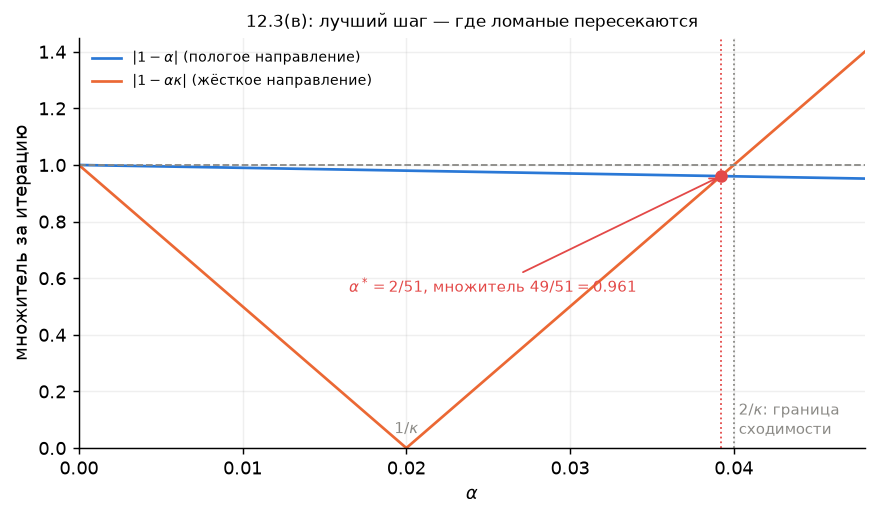

In [10]:
# (в): оба множителя как функции alpha
al = np.linspace(0, 2.4 / kappa, 500)
fig, ax = plt.subplots(figsize=(7.8, 4.1))
ax.plot(al, np.abs(1 - al), color=BLUE, label="$|1-\\alpha|$ (пологое направление)")
ax.plot(al, np.abs(1 - al * kappa), color=ORANGE, label="$|1-\\alpha\\kappa|$ (жёсткое направление)")
ax.axhline(1, color=GRAY, ls="--", lw=1)
ax.axvline(a_best, color=RED, ls=":", lw=1); ax.axvline(2 / kappa, color=GRAY, ls=":", lw=1)
ax.plot(a_best, rho(a_best), "o", color=RED, ms=6)
ax.annotate(f"$\\alpha^*=2/51$, множитель $49/51={rho(a_best):.3f}$", xy=(a_best, rho(a_best)), xytext=(0.0165, 0.55), fontsize=8.5,
            arrowprops=dict(arrowstyle="->", color=RED), color=RED)
ax.text(2 / kappa, 0.05, " $2/\\kappa$: граница\n сходимости", fontsize=8.5, color=GRAY)
ax.text(1 / kappa, 0.05, "$1/\\kappa$", fontsize=8.5, ha="center", color=GRAY)
ax.set_xlim(0, 2.4 / kappa); ax.set_ylim(0, 1.45)
ax.set_xlabel("$\\alpha$"); ax.set_ylabel("множитель за итерацию"); ax.legend(fontsize=8, loc="upper left")
ax.set_title("12.3(в): лучший шаг — где ломаные пересекаются", fontsize=9.5)
plt.show()

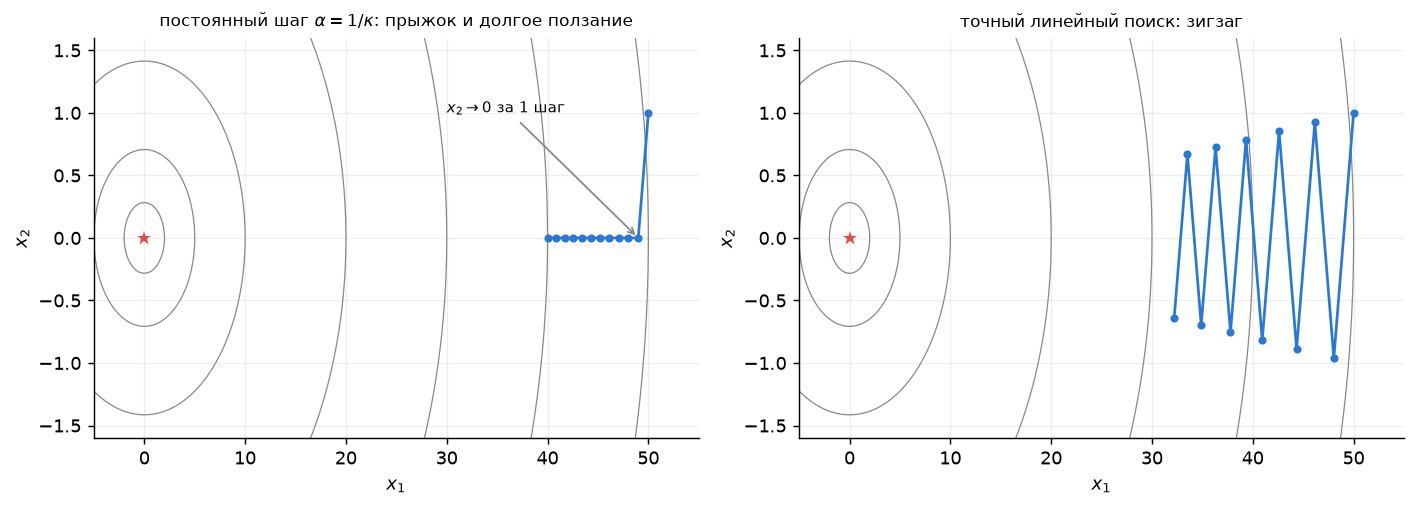

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.0))
xx, yy = np.meshgrid(np.linspace(-5, 55, 300), np.linspace(-2, 2, 200))
zz = 0.5 * (xx ** 2 + kappa * yy ** 2)
for ax, p, title in ((axs[0], p_const, "постоянный шаг $\\alpha=1/\\kappa$: прыжок и долгое ползание"),
                     (axs[1], p_ex, "точный линейный поиск: зигзаг")):
    ax.contour(xx, yy, zz, levels=0.5 * np.array([2, 5, 10, 20, 30, 40, 50]) ** 2, colors=GRAY, linewidths=0.7)
    ax.plot(p[:12, 0], p[:12, 1], "-o", ms=3.5, color=BLUE)
    ax.plot(0, 0, "*", ms=12, color=RED, mec="white")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_title(title, fontsize=9.5)
    ax.set_xlim(-5, 55); ax.set_ylim(-1.6, 1.6)
axs[0].annotate("$x_2\\to0$ за 1 шаг", xy=(49, 0), xytext=(30, 1.0), fontsize=8.5, arrowprops=dict(arrowstyle="->", color=GRAY))
plt.tight_layout(); plt.show()

In [12]:
# (д)-(е): километры, предобуславливание, Ньютон
D = np.diag([1e6, 1.0])
gu = lambda u: D @ u
u0 = np.array([1.0, 1.0])
print(f"(д) kappa в переменных u: 1e6;  итераций на цифру с шагом 1e-6: {np.log(10) / (-np.log(1 - 1e-6)):.2e}")

S = np.diag([1000.0, 1.0])                          # x = S u: обратно к метрам
u, x = u0.copy(), S @ u0
for _ in range(5):
    u = u - 0.7 * np.linalg.solve(D, gu(u))         # предобусловленный шаг в километрах
    x = x - 0.7 * x                                 # обычный спуск в метрах (grad f(x) = x)
    assert np.allclose(S @ u, x)
print(f"(е) 5 шагов: S u = {(S @ u).round(6)} = x = {x.round(6)} — траектории совпали")

u1 = u0 - np.linalg.solve(D, gu(u0))                # D = hess, alpha = 1: шаг Ньютона
print(f"    D = hess, alpha = 1: из {u0} сразу в {u1} — минимум за один шаг")
assert np.allclose(u1, 0)

(д) kappa в переменных u: 1e6;  итераций на цифру с шагом 1e-6: 2.30e+06
(е) 5 шагов: S u = [2.43e+00 2.43e-03] = x = [2.43e+00 2.43e-03] — траектории совпали
    D = hess, alpha = 1: из [1. 1.] сразу в [0. 0.] — минимум за один шаг


## 12.4. Розенброк: цена одной верной цифры

> (а) Гессиан в $(1,1)$. (б) Собственные числа и $\kappa$ — через след и определитель. (в) Оценка итераций на уменьшение ошибки в $10^6$ раз. (г) Сравнение с демо (c) и Ньютоном.
>
> *Суть: одно число $\kappa$ предсказывает тридцать тысяч итераций.*

**(а)** Дифференцируем $\nabla f=\big(-2(1-x_1)-400x_1(x_2-x_1^2),\ 200(x_2-x_1^2)\big)$ ещё раз:
$$\nabla^2f(1,1)=\begin{pmatrix}802&-400\\-400&200\end{pmatrix}.$$

**(б)** След $1002$, определитель $802\cdot200-400^2=400$. Когда собственные числа сильно разнесены, корень извлекать не нужно:
$$\lambda_{\max}\approx\operatorname{tr}=1002,\qquad \lambda_{\min}\approx\frac{\det}{\operatorname{tr}}\approx0.40,\qquad \kappa\approx\frac{\operatorname{tr}^2}{\det}\approx2510.$$
Точные значения: $1001.6$, $0.3994$, $\kappa=2508$ — приём ошибается на доли процента. Малое $\lambda$ — вдоль дна долины, большое — поперёк.

**(в)** Вблизи минимума работает картина 12.3: вдоль пологого направления множитель $1-1/\kappa$, и
$$n=\frac{\ln10^6}{-\ln(1-1/\kappa)}\approx\kappa\ln10^6\approx2508\cdot13.8\approx3.5\cdot10^4.$$

**(г)** Факты из демо: старт $(-1.2,\,1)$, стоп $\|\nabla f\|\le10^{-6}$.

| метод | итераций |
|---|---|
| шаг $0.001\approx1/\lambda_{\max}$ | $32\,076$ |
| шаг $0.0019$ (почти $2/\lambda_{\max}$) | $16\,851$ |
| backtracking | $13\,756$ |
| Ньютон | $7$ до $10^{-10}$, $6$ до $10^{-6}$ |

Оценка $3.5\cdot10^4$ и факт $32\,076$ — **одного порядка**; большего требовать нельзя: оценка — про сжатие вблизи минимума, факт — про весь путь из $(-1.2,1)$. Шаг вдвое ближе к границе — вдвое быстрее, как и предсказывает 12.3(в). При $\alpha>2/\lambda_{\max}\approx0.002$ метод **не сходится**: точка не улетает (изогнутая долина держит), но садится на 2-цикл поперёк долины, и $f$ перестаёт убывать. Ньютону $\kappa$ безразлично.

In [13]:
fr = lambda x: (1 - x[0]) ** 2 + 100 * (x[1] - x[0] ** 2) ** 2
gr = lambda x: np.array([-2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0] ** 2), 200 * (x[1] - x[0] ** 2)])
hr = lambda x: np.array([[2 - 400 * x[1] + 1200 * x[0] ** 2, -400 * x[0]], [-400 * x[0], 200.0]])

H = hr(np.array([1.0, 1.0]))
lam = np.linalg.eigvalsh(H)
kappa_r = lam[1] / lam[0]
tr, det = np.trace(H), np.linalg.det(H)
print(f"(а) гессиан в (1,1): {H.tolist()}")
print(f"(б) точно: lambda = {lam.round(4)}, kappa = {kappa_r:.0f};  приём: tr = {tr:.0f}, det/tr = {det / tr:.2f}, tr^2/det = {tr ** 2 / det:.0f}")
print(f"(в) оценка: kappa ln(1e6) = {kappa_r * np.log(1e6):.0f} итераций")

(а) гессиан в (1,1): [[802.0, -400.0], [-400.0, 200.0]]
(б) точно: lambda = [3.9940000e-01 1.0016006e+03], kappa = 2508;  приём: tr = 1002, det/tr = 0.40, tr^2/det = 2510
(в) оценка: kappa ln(1e6) = 34649 итераций


In [14]:
# (г): четыре запуска из (-1.2, 1)
x0 = np.array([-1.2, 1.0])
for name, a in (("шаг 0.001   ", 0.001), ("шаг 0.0019  ", 0.0019), ("backtracking", None)):
    _, k, _ = gd(fr, gr, x0, alpha=a)
    print(f"{name}: {k} итераций до ||grad|| <= 1e-6")
x_n, k_n, p_n = newton(gr, hr, x0)
_, k_n6, _ = newton(gr, hr, x0, tol=1e-6)
print(f"Ньютон      : {k_n} итераций до 1e-10, {k_n6} до 1e-6")
assert (k_n, k_n6) == (7, 6)

шаг 0.001   : 32076 итераций до ||grad|| <= 1e-6
шаг 0.0019  : 16851 итераций до ||grad|| <= 1e-6


backtracking: 13756 итераций до ||grad|| <= 1e-6
Ньютон      : 7 итераций до 1e-10, 6 до 1e-6


In [15]:
# за границей 2/lambda_max ~ 0.002: не расходимость, а 2-цикл поперёк долины
_, _, p_d = gd(fr, gr, x0, alpha=0.002, maxit=40_000)
print("шаг 0.002: последние f:", " <-> ".join(f"{fr(q):.4e}" for q in p_d[-4:]), f";  |x| <= {np.abs(p_d).max():.2f} — точка не улетела")

шаг 0.002: последние f: 1.2552e-03 <-> 1.2495e-03 <-> 1.2552e-03 <-> 1.2495e-03 ;  |x| <= 1.20 — точка не улетела


## 12.5. Прочитайте график

> Спуск с шагом $1/L$, старт $\|\nabla f(x_0)\|=1$, стоп $\|\nabla f\|\le10^{-8}$; $\log_{10}\|\nabla f(x_k)\|$ — прямая с наклоном $-0.0004$ на итерацию. (а) Множитель $q$ и $\kappa$? (б) Сколько итераций? (в) Масштабировать ли переменные? (г) Как выглядел бы Ньютон?
>
> *Суть: по одному наклону читаются множитель, $\kappa$ и цена цифры.*

**(а)** Прямая в полулогарифмических осях — это геометрическая прогрессия, и её наклон равен $\log_{10}q$. Отсюда $q=10^{-0.0004}\approx0.99908$. Для шага $1/L$ множитель равен $1-1/\kappa$, значит $\kappa=1/(1-q)\approx1090$. Удобная цепочка: наклон $-0.0004$ ⇒ одна цифра стоит $1/0.0004=2500$ итераций ⇒ $\kappa\approx2500/\ln10\approx1090$.

**(б)** От $1$ до $10^{-8}$ — восемь порядков: $8/0.0004=20\,000$ итераций.

**(в)** Да. При $\kappa\sim10^3$ каждая цифра стоит $\sim2500$ итераций, и если часть $\kappa$ пришла из масштабов переменных (12.3(д)), масштабирование заберёт её даром. График останется прямой — метод тот же, — но наклон станет круче: при $\kappa\approx3$ уже около $-0.2$, цифра за пять итераций.

**(г)** Не прямая, а «обрыв»: число верных цифр удваивается от шага к шагу, и расстояние между соседними точками графика растёт. От $1$ до $10^{-8}$ Ньютон доходит за $3$–$5$ итераций; вдали от минимума возможно плато и лишь потом срыв — как на Розенброке в 12.4.

**Проверка.** Квадратичная с $\kappa=1090$, старт с $\|\nabla f\|=1$, шаг $1/\lambda_{\max}$: наклон хвоста получается $\log_{10}(1-1/1090)\approx-0.000399$, итераций около $19$ тысяч. Расхождение с $20\,000$ в несколько процентов — нормально: прямая — это асимптотика; первые итерации быстро гасят жёсткие компоненты градиента, и линия стартует чуть ниже нуля.

In [16]:
# квадратичная с kappa = 1090: наклон хвоста и число итераций
kappa_5 = 1090.0
lam5 = np.logspace(0, np.log10(kappa_5), 10)        # диагональ гессиана от 1 до kappa
f5 = lambda x: 0.5 * x @ (lam5 * x)
g5 = lambda x: lam5 * x
x0_5 = (np.ones(10) / np.sqrt(10)) / lam5           # так ||grad f(x0)|| = 1
assert np.isclose(np.linalg.norm(g5(x0_5)), 1)

x5, k5, p5 = gd(f5, g5, x0_5, alpha=1 / lam5.max(), tol=1e-8)
lg5 = np.log10(np.linalg.norm(p5 * lam5, axis=1))
slope = (lg5[-1] - lg5[-5001]) / 5000
print(f"итераций: {k5} (условие даёт 20000);  наклон хвоста {slope:.6f}, log10(1 - 1/kappa) = {np.log10(1 - 1 / kappa_5):.6f}")
assert abs(slope - np.log10(1 - 1 / kappa_5)) < 1e-5 and abs(k5 - 20_000) / 20_000 < 0.1

итераций: 18815 (условие даёт 20000);  наклон хвоста -0.000399, log10(1 - 1/kappa) = -0.000399


In [17]:
# (г): Ньютон на гладкой сильно выпуклой (не квадратичной) функции — обрыв
gn_ = lambda x: np.tanh(x) + 0.1 * x
hn = lambda x: np.diag(1 / np.cosh(x) ** 2 + 0.1)
_, kn, pn = newton(gn_, hn, np.full(10, 0.9), tol=1e-8)
gnn = np.array([np.linalg.norm(gn_(q_)) for q_ in pn])
print(f"Ньютон: {kn} итераций, ||grad f_k|| = {np.array2string(gnn, precision=2)} — цифры удваиваются")

Ньютон: 4 итераций, ||grad f_k|| = [2.55e+00 1.55e+00 2.29e-01 6.05e-04 1.11e-11] — цифры удваиваются


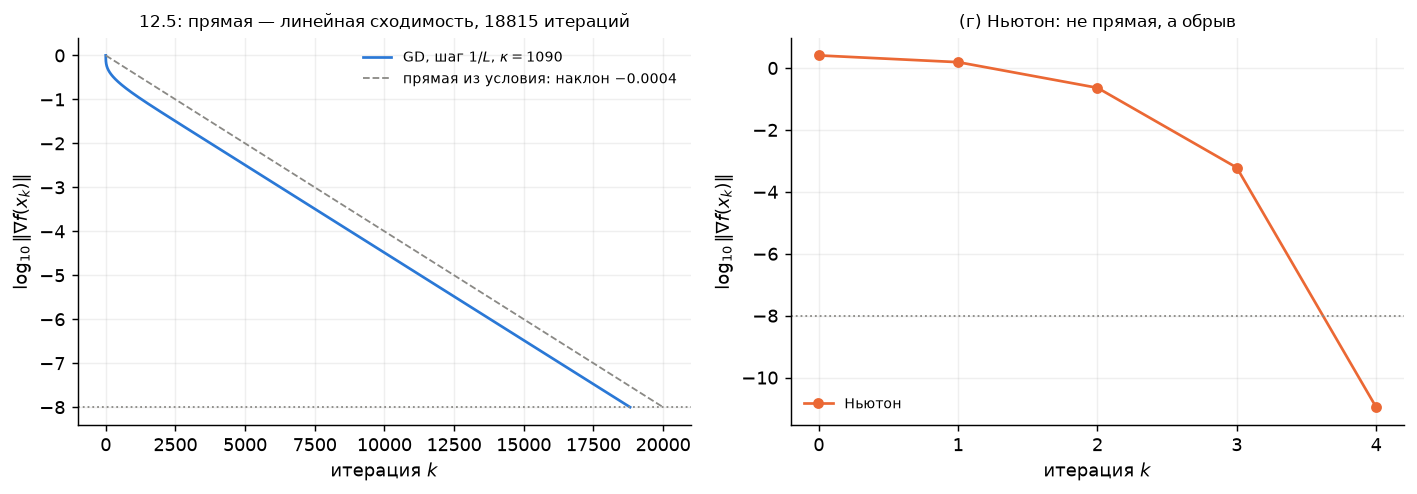

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.9))
ax = axs[0]
ax.plot(np.arange(len(lg5)), lg5, color=BLUE, lw=1.5, label="GD, шаг $1/L$, $\\kappa=1090$")
ax.plot([0, 20000], [0, -8], "--", color=GRAY, lw=1, label="прямая из условия: наклон $-0.0004$")
ax.axhline(-8, color=GRAY, ls=":", lw=1)
ax.set_xlabel("итерация $k$"); ax.set_ylabel("$\\log_{10}\\|\\nabla f(x_k)\\|$")
ax.set_title(f"12.5: прямая — линейная сходимость, {k5} итераций", fontsize=9.5); ax.legend(fontsize=8, loc="upper right")
ax = axs[1]
ax.plot(np.arange(len(gnn)), np.log10(gnn), "-o", color=ORANGE, ms=5, label="Ньютон")
ax.axhline(-8, color=GRAY, ls=":", lw=1)
ax.set_xlabel("итерация $k$"); ax.set_ylabel("$\\log_{10}\\|\\nabla f(x_k)\\|$")
ax.set_title("(г) Ньютон: не прямая, а обрыв", fontsize=9.5); ax.legend(fontsize=8, loc="lower left")
ax.set_xticks(np.arange(len(gnn)))
plt.tight_layout(); plt.show()

## 12.6. Лемма о спуске

> Дано $\|\nabla f(x)-\nabla f(y)\|\le L\|x-y\|$. (а) Докажите $f(y)\le f(x)+\nabla f(x)^\top(y-x)+\tfrac L2\|y-x\|^2$. (б) Подставьте $y=x-\alpha\nabla f(x)$. (в) Когда убывание гарантировано и какой шаг лучший? (г) $L$ для $\tfrac12x^\top Qx$?
>
> *Суть: главная формула раздела 4 выводится в три строки из одного интеграла.*

**(а)** Идём по отрезку $\gamma(t)=x+t(y-x)$. По формуле Ньютона–Лейбница
$$f(y)-f(x)=\int_0^1\nabla f(\gamma(t))^\top(y-x)\,dt.$$
Вычтем $\nabla f(x)^\top(y-x)$ — это тот же интеграл от постоянного вектора:
$$f(y)-f(x)-\nabla f(x)^\top(y-x)=\int_0^1\big(\nabla f(\gamma(t))-\nabla f(x)\big)^\top(y-x)\,dt.$$
Скалярное произведение не больше произведения норм, а по условию Липшица $\|\nabla f(\gamma(t))-\nabla f(x)\|\le L\,t\,\|y-x\|$. Остаётся проинтегрировать $L\,t\,\|y-x\|^2$ по $t$ от $0$ до $1$ — получается $\tfrac L2\|y-x\|^2$. Это верхняя парабола из раздела 4.3.

**(б)** При $y=x-\alpha\nabla f(x)$: линейный член равен $-\alpha\|\nabla f\|^2$, квадратичный — $\tfrac{L\alpha^2}2\|\nabla f\|^2$. Вместе:
$$f(x-\alpha\nabla f)\le f(x)-\alpha\Big(1-\frac{\alpha L}2\Big)\|\nabla f(x)\|^2.$$

**(в)** Гарантированное убывание $\psi(\alpha)=\alpha(1-\alpha L/2)\|\nabla f\|^2$ положительно при $0<\alpha<2/L$. Как парабола по $\alpha$, оно максимально в вершине $\alpha=1/L$, где убывание не меньше $\|\nabla f\|^2/(2L)$.

**(г)** $\nabla f=Qx$, и $\|Q(x-y)\|\le\lambda_{\max}(Q)\,\|x-y\|$ с равенством на старшем собственном векторе: $L=\lambda_{\max}(Q)$. Для дважды дифференцируемой $f$ вообще «$L$-липшицев градиент» $\iff$ $-LI\preceq\nabla^2f\preceq LI$, причём лемме достаточно верхней половины. На практике глобальная $L$ пессимистична: у Розенброка на прямоугольнике $[-2,2]\times[-1,3]$ она $\approx5327$, а у дна долины безопасен шаг на порядок больше $1/L$ — backtracking находит его сам.

In [19]:
# Розенброк: L по сетке на прямоугольнике и проверка неравенства на случайных парах
lo, hi = np.array([-2.0, -1.0]), np.array([2.0, 3.0])
grid = np.array([[a, b] for a in np.linspace(lo[0], hi[0], 101) for b in np.linspace(lo[1], hi[1], 101)])
L = max(np.linalg.eigvalsh(hr(q))[-1] for q in grid)
print(f"L = max lambda_max(hess) на прямоугольнике = {L:.0f};  1/L = {1 / L:.1e}")

rng = np.random.default_rng(0)
X = rng.uniform(lo, hi, size=(10_000, 2)); Y = rng.uniform(lo, hi, size=(10_000, 2))
lhs = np.array([fr(y) - fr(x) - gr(x) @ (y - x) for x, y in zip(X, Y)])
rhs = 0.5 * L * np.sum((Y - X) ** 2, axis=1)
print(f"max (f(y) - f(x) - grad^T(y-x)) / (L/2 |y-x|^2) по 10 000 парам = {np.max(lhs / rhs):.3f}  (должно быть <= 1)")
assert np.max(lhs / rhs) <= 1 + 1e-9

dec = [(fr(x) - fr(x - gr(x) / L)) / (gr(x) @ gr(x) / (2 * L)) for x in X[:2000]]
print(f"шаг 1/L: фактическое убывание / гарантированное по 2000 точкам >= {min(dec):.2f}  (должно быть >= 1)")
assert min(dec) >= 1 - 1e-9

L = max lambda_max(hess) на прямоугольнике = 5327;  1/L = 1.9e-04
max (f(y) - f(x) - grad^T(y-x)) / (L/2 |y-x|^2) по 10 000 парам = 0.799  (должно быть <= 1)
шаг 1/L: фактическое убывание / гарантированное по 2000 точкам >= 1.22  (должно быть >= 1)


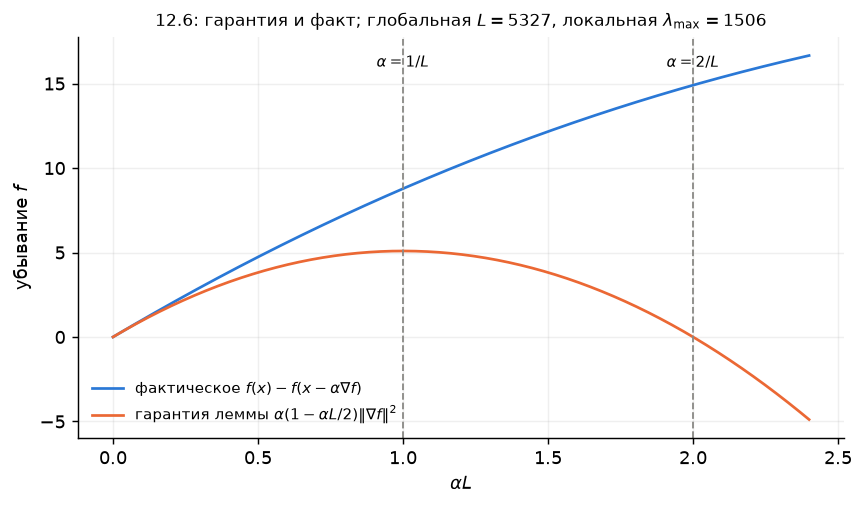

In [20]:
# гарантия и факт как функции alpha в точке (-1.2, 1)
x = np.array([-1.2, 1.0]); g = gr(x); L_loc = np.linalg.eigvalsh(hr(x))[-1]
alphas = np.linspace(0, 2.4 / L, 300)
actual = np.array([fr(x) - fr(x - a * g) for a in alphas])
guaranteed = alphas * (1 - alphas * L / 2) * (g @ g)
fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.plot(alphas * L, actual, color=BLUE, label="фактическое $f(x)-f(x-\\alpha\\nabla f)$")
ax.plot(alphas * L, guaranteed, color=ORANGE, label="гарантия леммы $\\alpha(1-\\alpha L/2)\\|\\nabla f\\|^2$")
ax.axvline(1, color=GRAY, ls="--", lw=1); ax.axvline(2, color=GRAY, ls="--", lw=1)
ax.text(1, ax.get_ylim()[1] * 0.9, "$\\alpha=1/L$", ha="center", fontsize=8.5); ax.text(2, ax.get_ylim()[1] * 0.9, "$\\alpha=2/L$", ha="center", fontsize=8.5)
ax.set_xlabel("$\\alpha L$"); ax.set_ylabel("убывание $f$"); ax.legend(fontsize=8.5, loc="lower left")
ax.set_title(f"12.6: гарантия и факт; глобальная $L={L:.0f}$, локальная $\\lambda_{{\\max}}={L_loc:.0f}$", fontsize=9.5)
plt.show()

## 12.7. Тип сходимости на слух

> Ошибки четырёх методов: (а) $10^{-1},10^{-2},10^{-3},\dots$; (б) $10^{-1},10^{-2},10^{-4},10^{-8},\dots$; (в) $1/k$; (г) $1/k!$. Тип сходимости каждой и число итераций от $\le10^{-1}$ до $\le10^{-12}$?
>
> *Суть: тип сходимости читается по отношению соседних ошибок.*

Смотрим на $\|e_{k+1}\|/\|e_k\|$: отделено от единицы одним $q<1$ — линейная; стремится к нулю — сверхлинейная; $\|e_{k+1}\|\le C\|e_k\|^2$ — квадратичная.

- **(а)** $e_k=10^{-k}$: отношение всегда $0.1$ — **линейная с множителем $0.1$**, цифра за итерацию. От $10^{-1}$ до $10^{-12}$ — **11** итераций.
- **(б)** $e_k=10^{-2^k}$: $e_{k+1}=e_k^2$ — **квадратичная**, число цифр удваивается: $1\to2\to4\to8\to16$. До $10^{-12}$ (первое значение — уже $10^{-16}$) — **4** итерации.
- **(в)** $e_k=1/k$: отношение $k/(k+1)\to1$ — не отделено от единицы, **не линейная** (сублинейная). Нужно $k\ge10^{12}$: **$\sim10^{12}$** итераций, на практике никогда.
- **(г)** $e_k=1/k!$: отношение $1/(k+1)\to0$ — **сверхлинейная**, но не квадратичная ($e_{k+1}/e_k^2\to\infty$). Первый раз $\le10^{-1}$ при $k=4$, $\le10^{-12}$ при $k=15$ — **11** итераций, как у (а): на коротком отрезке выигрыш сверхлинейности не успевает проявиться.

Порядок по скорости: (б) $\gg$ (г) $>$ (а) $\gg$ (в). Ньютон — это (б), квазиньютоновские методы — типа (г), спуск на сильно выпуклой функции — (а).

In [21]:
from math import factorial

seqs = {"(а) 10^-k  ": [10.0 ** -k for k in range(1, 6)],
        "(б) 10^-2^k": [10.0 ** -(2 ** k) for k in range(5)],
        "(в) 1/k    ": [1 / k for k in range(10, 15)],
        "(г) 1/k!   ": [1 / factorial(k) for k in range(3, 8)]}
for name, e in seqs.items():
    r = np.array(e[1:]) / np.array(e[:-1])
    print(f"{name} e_(k+1)/e_k = {np.array2string(r, precision=3)}")

first = lambda e, tol: next(k for k in range(10 ** 6) if e(k) <= tol)
for name, e in (("(а)", lambda k: 10.0 ** -k if k else 1.0), ("(б)", lambda k: 10.0 ** -(2 ** k)), ("(г)", lambda k: 1 / factorial(k))):
    print(f"{name} от 1e-1 до 1e-12: {first(e, 1e-12) - first(e, 1e-1)} итераций")
print("(в) от 1e-1 до 1e-12: 1e12 - 10 итераций")

(а) 10^-k   e_(k+1)/e_k = [0.1 0.1 0.1 0.1]
(б) 10^-2^k e_(k+1)/e_k = [1.e-01 1.e-02 1.e-04 1.e-08]
(в) 1/k     e_(k+1)/e_k = [0.909 0.917 0.923 0.929]
(г) 1/k!    e_(k+1)/e_k = [0.25  0.2   0.167 0.143]
(а) от 1e-1 до 1e-12: 11 итераций
(б) от 1e-1 до 1e-12: 4 итераций
(г) от 1e-1 до 1e-12: 11 итераций
(в) от 1e-1 до 1e-12: 1e12 - 10 итераций


## 12.8. Наискорейший спуск и ортогональность

> (а) Минимум $\nabla f^\top p$ по единичным $p$ — на антиградиенте. (б) $\nabla f$ ортогонален линии уровня. (в) При точном шаге $\nabla f(x_{k+1})\perp\nabla f(x_k)$.
>
> *Суть: три коротких доказательства о том, куда смотрит градиент.*

**(а)** Пусть $g=\nabla f(x)\ne0$. Для единичного $p$: $g^\top p=\|g\|\cos\theta\ge-\|g\|$, и равенство достигается только при $\theta=180^\circ$, то есть $p=-g/\|g\|$. Минимум производной по направлению равен $-\|g\|$ и достигается только на антиградиенте.

**(б)** Пусть $\gamma(t)$ — кривая на линии уровня, $\gamma(0)=x$: тождество $f(\gamma(t))=\mathrm{const}$. Дифференцируем по $t$ в нуле: $\nabla f(x)^\top\gamma'(0)=0$. Вектор $\gamma'(0)$ — любая касательная к линии уровня, значит $\nabla f$ перпендикулярен им всем.

**(в)** Точный шаг минимизирует $\varphi(\alpha)=f(x_k-\alpha g_k)$, и во внутреннем минимуме $\varphi'(\alpha_k)=-\nabla f(x_{k+1})^\top g_k=0$: следующий градиент перпендикулярен предыдущему, путь поворачивает на $90^\circ$ каждый шаг. По (б) это значит: остановились там, где луч шага коснулся линии уровня. В $\mathbb R^2$ направление через шаг повторяется точно — отсюда правильный зигзаг на картинке 04.

In [22]:
# (а): случайные направления не круче антиградиента; (в): ортогональность на зигзаге из 12.3
rng = np.random.default_rng(1)
x = np.array([-1.2, 1.0]); g = gr(x)
th = rng.uniform(0, 2 * np.pi, 10_000)
dd = np.c_[np.cos(th), np.sin(th)] @ g
print(f"(а) min g^T p по 10 000 случайным единичным p: {dd.min():.3f} >= -|g| = {-np.linalg.norm(g):.3f}")
assert dd.min() >= -np.linalg.norm(g)

gs = [gq(q) for q in p_ex[:7]]
cos = [gs[k] @ gs[k + 1] / (np.linalg.norm(gs[k]) * np.linalg.norm(gs[k + 1])) for k in range(6)]
print("(в) cos между соседними градиентами при точном шаге:", np.round(cos, 12))

(а) min g^T p по 10 000 случайным единичным p: -232.868 >= -|g| = -232.868
(в) cos между соседними градиентами при точном шаге: [ 0.  0. -0.  0. -0.  0.]


## 12.9. Цепь: решаем аналитически

> Цепь без пола: $N$ грузов массой $m=4/N$ на пружинах жёсткости $D$ между $(-2,1)$ и $(2,1)$, $E=\tfrac D2\sum_{i=0}^N\big[(y_{i+1}-y_i)^2+(z_{i+1}-z_i)^2\big]+mg\sum_{i=1}^N z_i$. (а) $N=1$ руками. (б) Общий $N$: почему $\nabla E=0$ — линейная система? (в) По $y$ грузы равномерны, по $z$ проверьте формулу $z_i=1-\frac{mg}{2D}\,i\,(N+1-i)$. (г) Почему это `np.linalg.solve` и один шаг Ньютона?
>
> *Суть: минимум энергии находится руками — условие $\nabla E=0$ линейно, и у решения есть явная формула.*

**(а) Один груз.** Две пружины и вес:
$$E(y,z)=\tfrac D2\big[(y+2)^2+(z-1)^2\big]+\tfrac D2\big[(2-y)^2+(1-z)^2\big]+mgz.$$
Приравниваем производные к нулю:
$$\frac{\partial E}{\partial y}=2Dy=0\ \Rightarrow\ y=0;\qquad
\frac{\partial E}{\partial z}=2D(z-1)+mg=0\ \Rightarrow\ z=1-\frac{mg}{2D}.$$
Груз висит посередине и провисает на $mg/(2D)$: при $m=4$, $D=70$ это $\approx0.28$, то есть $z\approx0.72$.

**(б) Общий $N$.** Координата $y_i$ входит ровно в две пружины, поэтому
$$\frac{\partial E}{\partial y_i}=D\,(2y_i-y_{i-1}-y_{i+1})=0,\qquad
\frac{\partial E}{\partial z_i}=D\,(2z_i-z_{i-1}-z_{i+1})+mg=0,$$
с краевыми $y_0=-2$, $y_{N+1}=2$, $z_0=z_{N+1}=1$. Каждое уравнение **линейно** — потому что $E$ квадратична: её градиент имеет вид $Hv+b$, и $\nabla E=0$ — система $Hv=-b$.

**(в) Решение руками.** По $y$: $2y_i=y_{i-1}+y_{i+1}$ — каждый $y_i$ есть среднее соседей, значит $y$ — арифметическая прогрессия от $-2$ до $2$: грузы по горизонтали расставлены **равномерно**, $y_i=-2+\tfrac{4i}{N+1}$. По $z$: подставим $z_i=1-a\,s_i$ с $s_i=i(N+1-i)$, $a=\tfrac{mg}{2D}$. Краевые условия выполнены ($s_0=s_{N+1}=0$), а вторая разность
$$2s_i-s_{i-1}-s_{i+1}=2,$$
поэтому $2z_i-z_{i-1}-z_{i+1}=-2a=-\tfrac{mg}D$ — ровно уравнение из (б). Цепь провисает по **дискретной параболе**; глубина в середине $\approx\tfrac{mg(N+1)^2}{8D}$, при $N=40$ это $\approx2.94$.

**(г)** Система (б) — это $Hv=-b$ с $b=\nabla E(0)$: её решает `np.linalg.solve(H, -grad_E(0))`. А для квадратичной $E$ ровно это делает один шаг Ньютона из любого старта (демо, части (0) и (d)): квадратичная модель точна, и шаг попадает в минимум сразу.

In [23]:
# (в): формулы против np.linalg.solve
D, g_acc = 70.0, 9.81
p_left, p_right = np.array([-2.0, 1.0]), np.array([2.0, 1.0])

def make_chain(N):
    m = 4.0 / N
    def unpack(v):
        return np.r_[p_left[0], v[:N], p_right[0]], np.r_[p_left[1], v[N:], p_right[1]]
    def energy(v):
        y, z = unpack(v)
        return 0.5 * D * np.sum(np.diff(y) ** 2 + np.diff(z) ** 2) + m * g_acc * np.sum(z[1:-1])
    def grad_E(v):
        y, z = unpack(v)
        return np.r_[D * (2 * y[1:-1] - y[:-2] - y[2:]), D * (2 * z[1:-1] - z[:-2] - z[2:]) + m * g_acc]
    K = 2 * np.eye(N) - np.eye(N, k=1) - np.eye(N, k=-1)
    H = np.kron(np.eye(2), D * K)
    v0 = np.r_[np.linspace(p_left[0], p_right[0], N + 2)[1:-1], np.linspace(p_left[1], p_right[1], N + 2)[1:-1]]
    return energy, grad_E, unpack, K, H, v0

N = 40
energy, grad_E, unpack, K, H, v0 = make_chain(N)
v_solve = np.linalg.solve(H, -grad_E(np.zeros(2 * N)))

i = np.arange(1, N + 1)
a = (4.0 / N) * g_acc / (2 * D)
y_formula = -2 + 4 * i / (N + 1)
z_formula = 1 - a * i * (N + 1 - i)
print(f"max |y_формула - y_solve| = {np.abs(y_formula - v_solve[:N]).max():.2e}")
print(f"max |z_формула - z_solve| = {np.abs(z_formula - v_solve[N:]).max():.2e}")
print(f"глубина провиса в середине: {1 - z_formula.min():.3f}  (формула mg(N+1)^2/(8D) = {(4.0 / N) * g_acc * (N + 1) ** 2 / (8 * D):.3f})")
print(f"энергия в минимуме: {energy(v_solve):.4f}")
assert np.allclose(np.r_[y_formula, z_formula], v_solve, atol=1e-9)
assert abs(energy(v_solve) - 13.4417) < 5e-4

max |y_формула - y_solve| = 2.22e-15
max |z_формула - z_solve| = 1.22e-14
глубина провиса в середине: 2.943  (формула mg(N+1)^2/(8D) = 2.945)
энергия в минимуме: 13.4417


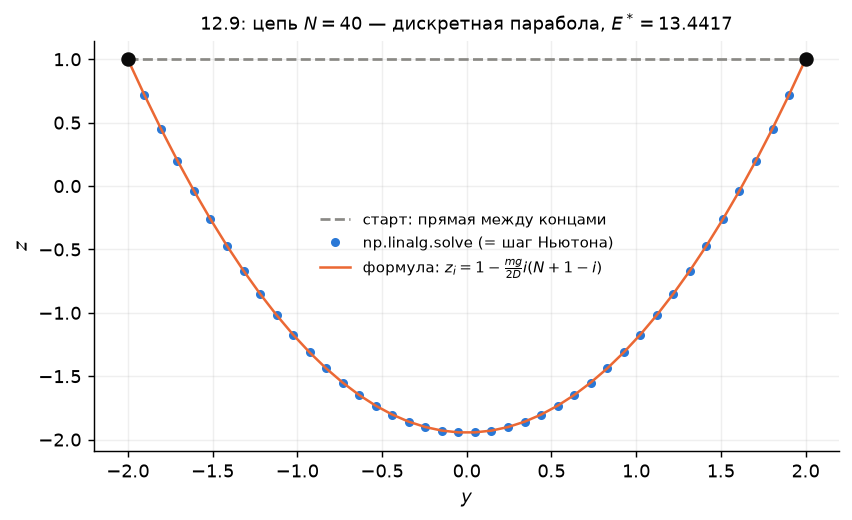

In [24]:
y0, z0 = unpack(v0); ys, zs = unpack(v_solve)
fig, ax = plt.subplots(figsize=(7.4, 4.1))
ax.plot(y0, z0, "--", color=GRAY, label="старт: прямая между концами")
ax.plot(ys, zs, "o", ms=4, color=BLUE, label="np.linalg.solve (= шаг Ньютона)")
ax.plot(np.r_[-2, y_formula, 2], np.r_[1, z_formula, 1], "-", color=ORANGE, lw=1.4,
        label="формула: $z_i=1-\\frac{mg}{2D}i(N+1-i)$")
ax.plot([-2, 2], [1, 1], "o", color=INK, ms=7)
ax.set_xlabel("$y$"); ax.set_ylabel("$z$"); ax.legend(fontsize=8.5, loc="center")
ax.set_title(f"12.9: цепь $N={N}$ — дискретная парабола, $E^*={energy(v_solve):.4f}$", fontsize=10)
plt.show()

## 12.10. CasADi: та же задача в несколько строк

> (а) Опишите Розенброка символьно и получите градиент и гессиан автоматически; сверьте гессиан в $(1,1)$ с 12.4. (б) Решите задачу солвером IPOPT из $(-1.2,\,1)$. (в) Соберите энергию цепи символьно и решите; сверьте с параболой из 12.9.
>
> *Суть: градиенты и гессианы, которые мы писали руками, инструмент строит сам — и решает задачу готовым солвером.*

Нужен пакет CasADi: `uv sync --group casadi` в корне репозитория. Основы — раздел 11.1 конспекта; две первые ячейки повторяют их в коде.

**Основы.** Символьная переменная — имя без значения; выражение не вычисляется, а запоминается как дерево операций.

In [25]:
import casadi as ca

t = ca.SX.sym("t")                      # переменная без значения
g = (1 - t) ** 2                        # дерево операций, не число
print("дерево:", g)
G = ca.Function("G", [t], [g])          # дерево -> вычислимая функция
print("G(3) =", G(3))

дерево: sq((1-t))
G(3) = 4


Производная — операция над деревом: `jacobian` строит по нему **новое** дерево по правилам дифференцирования. Ни шага $h$, ни погрешности — значение точное.

In [26]:
dg = ca.jacobian(g, t)                  # дерево производной
dG = ca.Function("dG", [t], [dg])
print("dG(3) =", dG(3), " (вручную: -2*(1-3) = 4)")
assert float(dG(3)) == 4.0

dG(3) = 4  (вручную: -2*(1-3) = 4)


**(а)** Розенброк символьно: градиент и гессиан одной командой — те же $802$ и $-400$, что в 12.4.

In [27]:
x = ca.SX.sym("x", 2)
f = (1 - x[0]) ** 2 + 100 * (x[1] - x[0] ** 2) ** 2
grad_f = ca.Function("g", [x], [ca.gradient(f, x)])
hess_f = ca.Function("H", [x], [ca.hessian(f, x)[0]])
print("градиент в (1,1):", grad_f([1, 1]))
print("гессиан  в (1,1):", hess_f([1, 1]))
assert np.allclose(np.array(hess_f([1, 1])), [[802, -400], [-400, 200]])

градиент в (1,1): [-0, 0]
гессиан  в (1,1): 
[[802, -400], 
 [-400, 200]]


**(б)** Отдаём задачу солверу IPOPT: пара десятков итераций против $13\,756$ у спуска из демо (c).

In [28]:
opts = {"ipopt.print_level": 0, "print_time": 0}
S = ca.nlpsol("S", "ipopt", {"x": x, "f": f}, opts)
sol = S(x0=[-1.2, 1.0])
x_star = np.array(sol["x"]).ravel()
print(f"решение: {x_star.round(8)},  итераций IPOPT: {S.stats()['iter_count']}  (GD с backtracking: 13 756)")
assert np.allclose(x_star, [1, 1], atol=1e-6)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

решение: [1. 1.],  итераций IPOPT: 21  (GD с backtracking: 13 756)


**(в)** Цепь: энергия собирается циклом по пружинам — как на доске в 12.9, — решение совпадает с параболой.

In [29]:
v = ca.SX.sym("v", 2 * N)                       # N = 40 из 12.9
yc = ca.vertcat(-2, v[:N], 2)
zc = ca.vertcat(1, v[N:], 1)
E = 0
for j in range(N + 1):                           # цикл по пружинам — как в формуле энергии
    E += D / 2 * ((yc[j + 1] - yc[j]) ** 2 + (zc[j + 1] - zc[j]) ** 2)
E += (4.0 / N) * g_acc * ca.sum1(zc[1:N + 1])    # вес грузов

S_chain = ca.nlpsol("S_chain", "ipopt", {"x": v, "f": E}, opts)
v_ca = np.array(S_chain(x0=np.zeros(2 * N))["x"]).ravel()
print(f"энергия: {float(S_chain(x0=np.zeros(2 * N))['f']):.4f}  (из 12.9: 13.4417)")
print(f"max |z_casadi - z_формула| = {np.abs(v_ca[N:] - z_formula).max():.1e};  max |y_casadi - y_формула| = {np.abs(v_ca[:N] - y_formula).max():.1e}")
assert np.allclose(v_ca, np.r_[y_formula, z_formula], atol=1e-5)

энергия: 13.4417  (из 12.9: 13.4417)
max |z_casadi - z_формула| = 8.9e-16;  max |y_casadi - y_формула| = 6.7e-16


Итог: символьные переменные → функция → солвер. Производные точные и бесплатные, но выбирать метод, читать график сходимости и чинить плохое $\kappa$ инструмент за вас не будет.

## 12.11. Цепь: $\kappa$ растёт с числом грузов

> Продолжение 12.9: гессиан $\operatorname{diag}(DK,\,DK)$ там уже выписан. (а) По $\lambda_j(K)=2-2\cos\frac{j\pi}{N+1}$ найдите $\kappa(N)$. (б) Покажите $\kappa\approx(2(N+1)/\pi)^2$. (в) $N=40$: итераций спуска против одного шага Ньютона.
>
> *Суть: чем мельче дробим задачу, тем хуже она обусловлена — $\kappa\sim N^2$.*

**(а)** $\lambda_{\min}(K)=2-2\cos\frac\pi{N+1}$, а $\lambda_{\max}(K)=2+2\cos\frac\pi{N+1}$ (у $j=N$ косинус поменял знак). Общий множитель $D$ сокращается:
$$\kappa(N)=\frac{1+\cos\frac\pi{N+1}}{1-\cos\frac\pi{N+1}}.$$

**(б)** При больших $N$ угол $\theta=\pi/(N+1)$ мал и $\cos\theta\approx1-\theta^2/2$: числитель $\approx2$, знаменатель $\approx\theta^2/2$, значит
$$\kappa\approx\frac4{\theta^2}=\Big(\frac{2(N+1)}\pi\Big)^2\ \sim\ N^2.$$
Для $N=10,20,40,80$: $\kappa=48.4,\ 178.1,\ 680.6,\ 2658.4$; формула даёт $49.0,\ 178.7,\ 681.3,\ 2659.1$.

**(в)** $N=40$: $\kappa\approx681$, $L=D\,\lambda_{\max}(K)\approx279.6$. Стартовый градиент $\|\nabla E(v_0)\|\approx6.2$, стоп по $10^{-6}$ — уменьшить в $6.2\cdot10^6$ раз: оценка $\kappa\ln(6.2\cdot10^6)\approx10\,640$ итераций, факт — $10\,575$: функция квадратична, асимптотика работает с первого шага. Ньютон (12.9(е)) решает ту же задачу одной линейной системой.

In [30]:
# (а)-(б): kappa(N) против формулы; (в): спуск против Ньютона
print(" N   kappa(K)   (2(N+1)/pi)^2")
for n in (10, 20, 40, 80):
    ev = np.linalg.eigvalsh(2 * np.eye(n) - np.eye(n, k=1) - np.eye(n, k=-1))
    print(f"{n:3d}  {ev[-1] / ev[0]:9.1f}  {(2 * (n + 1) / np.pi) ** 2:12.1f}")

lamH = np.linalg.eigvalsh(H)
L, kappa_c = lamH[-1], lamH[-1] / lamH[0]
gn0 = np.linalg.norm(grad_E(v0))
v_gd, k_gd, _ = gd(energy, grad_E, v0, alpha=1 / L)
print(f"N = 40: L = {L:.1f}, kappa = {kappa_c:.1f};  оценка kappa*ln(||grad E(v0)||/1e-6) = {kappa_c * np.log(gn0 / 1e-6):.0f}")
print(f"GD с шагом 1/L: {k_gd} итераций;  расстояние до решения из 12.9: {np.linalg.norm(v_gd - v_solve):.1e}")
assert abs(k_gd - 10_575) <= 5

 N   kappa(K)   (2(N+1)/pi)^2
 10       48.4          49.0
 20      178.1         178.7
 40      680.6         681.3
 80     2658.4        2659.1


N = 40: L = 279.6, kappa = 680.6;  оценка kappa*ln(||grad E(v0)||/1e-6) = 10645
GD с шагом 1/L: 10575 итераций;  расстояние до решения из 12.9: 2.4e-06


## Что запомнить

- $\nabla f=0$ — необходимое условие: спуск останавливается в любой стационарной точке, в том числе в седле, но к седлу приходит только со множества меры нуль (12.1). Нулевое собственное число гессиана — условия молчат, решают старшие члены; проверка «по направлениям» не заменяет $\nabla^2f\succ0$ (12.2).
- На квадратичной с постоянным шагом ошибка по каждому собственному направлению сжимается в $|1-\alpha\lambda_i|$ раз; сходимость при $0<\alpha<2/\lambda_{\max}$, лучший шаг $2/(\lambda_{\max}+\lambda_{\min})$ с множителем $(\kappa-1)/(\kappa+1)$; итераций на цифру $\sim\kappa$ (12.3, 12.4, 12.11).
- $\kappa$ — свойство координат: масштабирование переменных — самый дешёвый предобусловливатель (12.3(д)–(е)).
- Наклон прямой $\log_{10}\|\nabla f_k\|$ равен $\log_{10}(1-1/\kappa)$: по графику читаются $\kappa$ и цена цифры (12.5).
- Лемма о спуске: при $\nabla^2f\preceq LI$ шаг $1/L$ гарантирует убывание на $\|\nabla f\|^2/(2L)$; для квадратичной $L=\lambda_{\max}$; глобальная $L$ пессимистична, backtracking находит локальную (12.6).
- Тип сходимости — по отношению соседних ошибок: отделено от единицы — линейная, $\to0$ — сверхлинейная, $\|e_{k+1}\|\le C\|e_k\|^2$ — квадратичная (12.7).
- Антиградиент — самый крутой спуск и перпендикуляр к линии уровня; при точном шаге соседние градиенты ортогональны — зигзаг (12.8).
- Минимум квадратичной функции — решение линейной системы $\nabla E=Hv+b=0$: у цепи оно выписывается руками, и это же — один шаг Ньютона (12.9, 12.11).
- Производные не обязательно писать руками: CasADi строит градиент и гессиан по символьной записи и решает задачу IPOPT'ом (12.10) — но выбирать метод и читать график сходимости инструмент за вас не будет.